# Regressão Softmax com dados do MNIST utilizando gradiente descendente estocástico por minibatches

O objetivo deste notebook é ilustrar
- o uso do gradiente estocástico por mini-batchs
- utilizando as classes Dataset e DataLoater.

A apresentação da perda nos gráficos é um pouco diferente da usual, mostrando a perda de cada um dos vários minibatches dentro de cada época, de forma que as épocas são apresentadas com valores fracionários.

## Importação das bibliotecas

In [13]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import MNIST

## Dataset e dataloader

### Definição do tamanho do minibatch

In [14]:
batch_size = 100

### Carregamento, criação dataset e do dataloader

In [15]:
dataset_dir = 'MNIST/'

dataset_train = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

print('Número de minibatches de trenamento:', len(loader_train))

x_train, y_train = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch:", x_train.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:         ", type(x_train))
print("Tipo das classes das imagens:       ", type(y_train))

Número de minibatches de trenamento: 600

Dimensões dos dados de um minibatch: torch.Size([100, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>


### Usando todas as amostras do MNIST

Neste exemplo utilizaremos todas as amostras de treinamento.

In [16]:
print('Número de minibatches de trenamento:', len(loader_train))
n_batches_train = len(loader_train)
total_samples = dataset_train.train_data.size(0)

Número de minibatches de trenamento: 600


## Modelo

In [17]:
model = torch.nn.Linear(28*28, 10)

In [18]:
x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)
predict

torch.Size([1, 784])


tensor([[-0.5053,  0.1111, -0.6661,  1.1592,  0.3283, -0.0163, -0.4852, -0.6825,
          0.0710,  0.7166]], grad_fn=<AddmmBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [19]:
n_epochs = 5
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos parâmetros

In [20]:
epochs = []
losses = []

total_trained_samples = 0
for i in range(n_epochs):
    for k,(x_train, y_train) in enumerate(loader_train):
        # Transforma a entrada para uma dimensão
        inputs = Variable(x_train.view(-1, 28 * 28))
        # predict da rede
        outputs = model(inputs)

        # calcula a perda
        loss = criterion(outputs, Variable(y_train))

        # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_trained_samples += x_train.size(0)
        epochs.append(total_trained_samples / total_samples)
        losses.append(loss.data)

In [21]:
print('Final loss:', loss.data)

Final loss: tensor(0.2402)


### Visualizando gráfico de perda durante o treinamento

Text(0.5, 0, 'época')

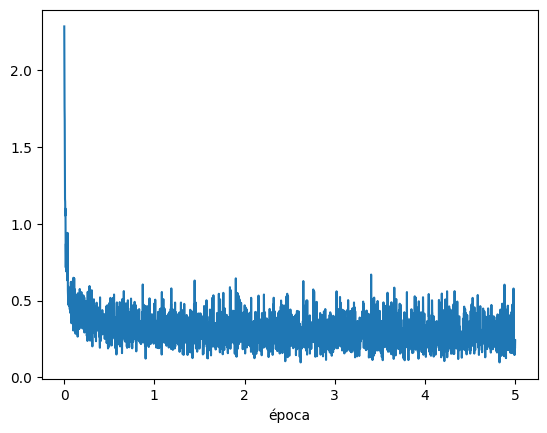

In [22]:
plt.plot(epochs, losses)
plt.xlabel('época')

### Visualização usual da perda, somente no final de cada minibatch

Text(0.5, 0, 'época')

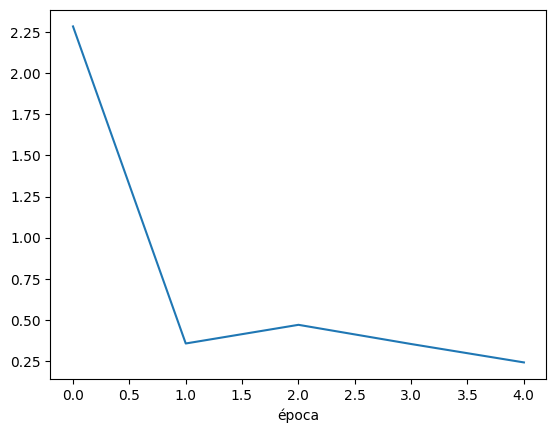

In [23]:
plt.plot(epochs[:5 * n_batches_train +1:n_batches_train], losses[:5 * n_batches_train+1:n_batches_train])
plt.xlabel('época')

# Atividades

## Perguntas

1. Qual é o tamanho do mini-batch?

    100

2. Em uma época, quantos mini-batches existem?

    Há 600 mini-batches por época

3. Qual é a definição de época?

    Uma passagem completa por todo o conjunto de treinamento.


## Exercícios


1. Coloque um print no final de cada minibatch, no mesmo estilo do print do final de época, no seguinte estilo:
    - Época: 1/4, batch: 600
2. Altere o tamanho de minibatch (batch_size) algumas vezes, refaça o treinamento, e compare no gráfico abaixo a queda da perda para cada tamanho de minibatch.

### Questao 01

In [24]:
n_batches_train = len(loader_train)  # número total de minibatches por época

epochs = []
losses = []

total_trained_samples = 0
for i in range(n_epochs):
    for k, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        outputs = model(inputs)

        loss = criterion(outputs, Variable(y_train))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_trained_samples += x_train.size(0)
        epochs.append(total_trained_samples / total_samples)
        losses.append(loss.item())

        # print por minibatchs por epoca
        print(f"Época: {i+1}/{n_epochs}, batch: {k+1}/{n_batches_train}, loss: {loss.item():.4f}")


Época: 1/5, batch: 1/600, loss: 0.1282
Época: 1/5, batch: 2/600, loss: 0.2734
Época: 1/5, batch: 3/600, loss: 0.3630
Época: 1/5, batch: 4/600, loss: 0.2583
Época: 1/5, batch: 5/600, loss: 0.2581
Época: 1/5, batch: 6/600, loss: 0.2956
Época: 1/5, batch: 7/600, loss: 0.2538
Época: 1/5, batch: 8/600, loss: 0.2045
Época: 1/5, batch: 9/600, loss: 0.3033
Época: 1/5, batch: 10/600, loss: 0.4408
Época: 1/5, batch: 11/600, loss: 0.1558
Época: 1/5, batch: 12/600, loss: 0.2280
Época: 1/5, batch: 13/600, loss: 0.2244
Época: 1/5, batch: 14/600, loss: 0.2340
Época: 1/5, batch: 15/600, loss: 0.1682
Época: 1/5, batch: 16/600, loss: 0.2297
Época: 1/5, batch: 17/600, loss: 0.1402
Época: 1/5, batch: 18/600, loss: 0.3596
Época: 1/5, batch: 19/600, loss: 0.3042
Época: 1/5, batch: 20/600, loss: 0.4387
Época: 1/5, batch: 21/600, loss: 0.3431
Época: 1/5, batch: 22/600, loss: 0.1414
Época: 1/5, batch: 23/600, loss: 0.3154
Época: 1/5, batch: 24/600, loss: 0.1207
Época: 1/5, batch: 25/600, loss: 0.5768
Época: 1/

### Questao 02

In [25]:
batch_sizes = [60, 180, 300, 600]
results = {} # para guardar losses de cada batch_size

for bs in batch_sizes:
    print(f"\nTreinando com batch_size = {bs}")

    # recria dataset/dataloader
    loader_train = DataLoader(dataset_train, batch_size=bs, shuffle=True)
    n_batches_train = len(loader_train)

    # recria o modelo zerado
    model = torch.nn.Linear(28*28, 10)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

    # listas para este experimento
    epochs = []
    losses = []
    total_trained_samples = 0

    for i in range(n_epochs):
        for k, (x_train, y_train) in enumerate(loader_train):
            inputs = Variable(x_train.view(-1, 28 * 28))
            outputs = model(inputs)
            loss = criterion(outputs, Variable(y_train))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_trained_samples += x_train.size(0)
            # fração de época (para eixo x ficar comparável)
            epochs.append(total_trained_samples / total_samples)
            losses.append(loss.item())

            # print minibatchs por epoca
            # print(f"Época: {i+1}/{n_epochs}, batch: {k+1}/{n_batches_train}, loss: {loss.item():.4f}")

    results[bs] = (epochs, losses)



Treinando com batch_size = 60

Treinando com batch_size = 180

Treinando com batch_size = 300

Treinando com batch_size = 600


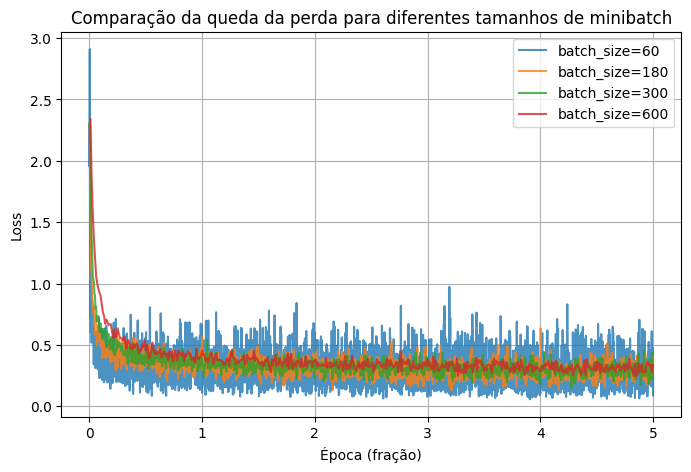

In [26]:
plt.figure(figsize=(8,5))

for bs, (eps, los) in results.items():
    plt.plot(eps, los, label=f"batch_size={bs}", alpha=0.8)

plt.xlabel("Época (fração)")
plt.ylabel("Loss")
plt.title("Comparação da queda da perda para diferentes tamanhos de minibatch")
plt.legend()
plt.grid(True)
plt.show()

## Conclusões sobre os experimentos deste notebook


Tamanhos menores de minibatch resultam em curvas de perda mais ruidosas e atualizações mais frequentes, enquanto tamanhos maiores produzem curvas mais suaves e estáveis. Embora o comportamento durante o treinamento seja diferente, os valores finais da perda tendem a ser semelhantes.